# <ins>Übung 05 - Musterlösung</ins>

## Einführung: NumPy Arrays

In dieser Übung arbeiten wir mit **NumPy**, der zentralen Bibliothek für numerische Berechnungen in Python. Das wichtigste Konzept ist der **NumPy-Array** (`ndarray`) – eine schnelle, speichereffiziente Alternative zu Python-Listen, die direkte mathematische Operationen auf ganzen Datensätzen ermöglicht.

### Arrays erstellen

```python
import numpy as np

# Aus einer Liste
a = np.array([1, 2, 3, 4, 5])

# Gleichmäßig verteilte Werte (von, bis, Anzahl)
b = np.linspace(0, 10, 5)      # [0., 2.5, 5., 7.5, 10.]

# Gleichmäßige Schrittweite
c = np.arange(0, 10, 2)        # [0, 2, 4, 6, 8]
```

### Indexierung und Slicing

```python
a = np.array([10, 20, 30, 40, 50])

a[0]      # 10  – erstes Element
a[-1]     # 50  – letztes Element
a[1:3]    # [20, 30]  – Elemente 1 bis 2
a[1:]     # [20, 30, 40, 50]  – ab Index 1
a[:-1]    # [10, 20, 30, 40]  – alle außer dem letzten
```

### Elementweise Operationen

Im Gegensatz zu Python-Listen werden Rechenoperationen **auf jedes Element** angewendet:

```python
a = np.array([1, 2, 3, 4])

a * 2          # [2, 4, 6, 8]
a ** 2         # [1, 4, 9, 16]
a[1:] - a[:-1] # Differenzen benachbarter Elemente: [1, 1, 1]
```

### 2D-Arrays (Matrizen)

```python
# np.loadtxt liefert oft 2D-Arrays
data = np.loadtxt('datei.txt')   # Form: (Zeilen, Spalten)
data[:, 0]   # gesamte erste Spalte
data[:, 1]   # gesamte zweite Spalte
data[0, :]   # erste Zeile
```

**Aufgabe N1** – Erstellen Sie mit `np.array()` ein Array mit den ganzen Zahlen von 1 bis 5. Erstellen Sie außerdem mit `np.linspace()` ein Array mit 6 gleichmäßig verteilten Werten zwischen 0 und 10. Geben Sie beide Arrays aus.

In [ ]:
import numpy as np

a = np.array([1, 2, 3, 4, 5])
b = np.linspace(0, 10, 6)
print('Array a:', a)
print('Array b:', b)

**Aufgabe N2** – Iterieren Sie mit einer `for`-Schleife über Ihr erstes Array und geben Sie jedes Element aus.

In [ ]:
for x in a:
    print(x)

**Aufgabe N3** – Berechnen Sie ohne Schleife: das Quadrat jedes Elements und das Dreifache jedes Elements. Geben Sie die Ergebnisse aus.

In [ ]:
print('Quadrat:', a**2)
print('Dreifaches:', a * 3)

**Aufgabe N4** – Gegeben ist das Höhenarray `h = np.array([10, 15, 12, 20, 25])`. Berechnen Sie die Differenzen zwischen benachbarten Elementen mit Array-Slicing.

In [ ]:
h = np.array([10, 15, 12, 20, 25])
differenzen = h[1:] - h[:-1]
print('Differenzen:', differenzen)

<details>
<summary><div style="border:1px solid #3c763d;background-color:#dff0d8;padding:10px;border-radius:5px;margin:10px 0;cursor:pointer;"><strong>✅ Verbindung zur Ballonfahrt</strong> (zum Aufklappen)</div></summary>
<div style="border:1px solid #3c763d;background-color:#dff0d8;padding:10px;border-radius:5px;margin-top:-8px;">
Das Slicing-Muster <code>a[1:] - a[:-1]</code> berechnet die Differenz zwischen je zwei benachbarten Elementen – das ist genau der <strong>Differenzenquotient</strong>, den Sie gleich für die Steiggeschwindigkeit des Ballons benötigen:
$$v(t_i) = \frac{h(i) - h(i-1)}{t(1) - t(0)}$$
</div>
</details>

## Ballonfahrt

In der Datei `messdaten_ballonfahrt.txt` finden Sie die Messdaten der Höhe eines Ballons während einer Ballonfahrt. In den ersten Zeilen der Datei sind Kommentarzeilen, die die Randbedingungen und den Aufbau der Messdatei beschreiben.

Gesucht ist ein Polynom, das die Steiggeschwindigkeit, also die Änderung der Höhe mit der Zeit, des Heißluftballons beschreibt. Dies soll in zwei unterschiedlichen Wegen implementiert werden.

### Aufgabenteil A

Schreiben Sie ein Programm, das die Höhe aus den Daten ausliest, die Steiggeschwindigkeit berechnet und einen Fit der Geschwindigkeit mit einem Polynom dritten Grades durchführt. Plotten Sie die Höhe, die Geschwindigkeit und den Fit jeweils gegen die Zeit. Beschriften Sie die Achsen und erstellen Sie eine Legende.

#### Schritt für Schritt Anleitung:

1. Importieren Sie die passenden Pakete
2. Laden Sie jeweils die Zeitdaten und die Höhendaten in eine Liste
3. Berechnen Sie die Steiggeschwindigkeit mit Hilfe des Differenzenquotienten (für äquidistante Zeitabstände) und erzeugen Sie eine dazu passende Zeitliste
$$ v(t(i)) = \frac{h(i)-h(i-1)}{t(1)-t(0)} $$
4. Fitten Sie die Geschwindigkeit
5. Plotten Sie die Höhe, die Geschwindigkeit und den Fit jeweils gegen die Zeit

<div style="border:1px solid #3c763d;background-color:#dff0d8;padding:10px;border-radius:5px;margin:10px 0;">
<strong>✅ Hinweis:</strong> Nutzen Sie <code>np.loadtxt('messdaten_ballonfahrt.txt', skiprows=4, delimiter=';')</code> um die Daten einzulesen. Die ersten 4 Zeilen enthalten Kommentare und ungültige Werte. Mit <code>data[:, 0]</code> bzw. <code>data[:, 1]</code> greifen Sie auf Zeit- bzw. Höhenspalte zu.
</div>

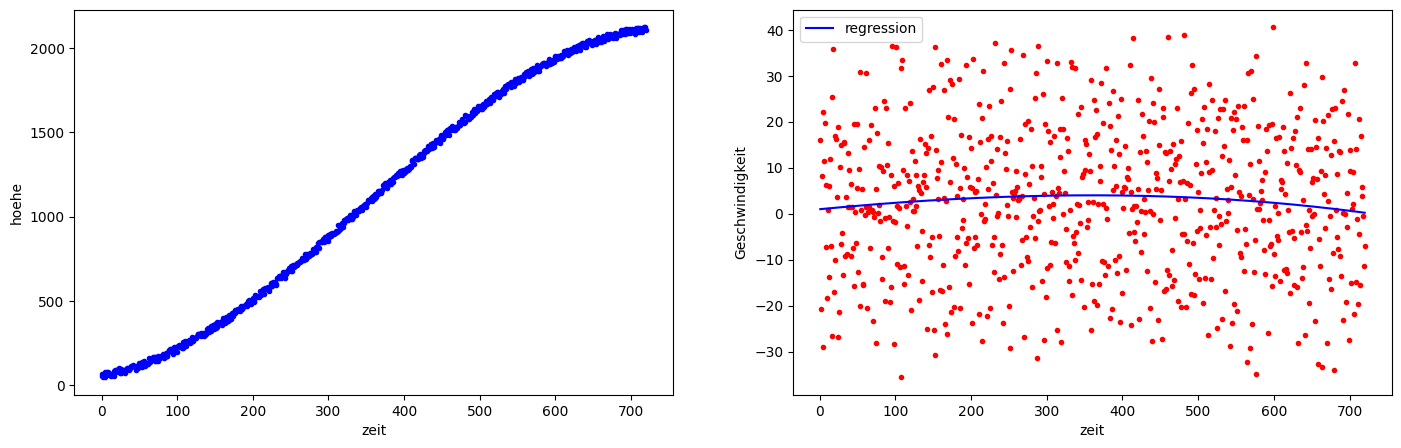

In [ ]:
# Importieren der passenden Pakete
import numpy as np
import matplotlib.pyplot as plt
data = np.loadtxt('messdaten_ballonfahrt.txt', skiprows= 4, delimiter=';')

# Zeit- und Höhendaten in eine Liste laden
zeit = data[:, 0]
hoehe = data[:, 1]

# Steiggeschwindigkeit berechnen
v = (hoehe[1:] - hoehe[:-1])/(zeit[1]-zeit[0])
t_v = zeit[1:]

# Fit der Geschwindigkeit:
v_P = np.polyfit(t_v, v, 3)

# neue x-Stützstellen erstellen:
t_v_reg = np.linspace(np.min(t_v), np.max(t_v), 1000)
v_reg = np.polyval(v_P, t_v_reg)

# Erstellung der Plots
plt.figure(figsize=[17,5])
plt.subplot(121)
plt.plot(zeit, hoehe, '.b')
plt.xlabel('zeit')
plt.ylabel('hoehe')

plt.subplot(122)
plt.plot(t_v, v, '.r')
plt.xlabel('zeit')
plt.ylabel('Geschwindigkeit')


plt.plot(t_v_reg, v_reg, 'b', label='regression')
plt.xlabel('zeit')
plt.ylabel('Geschwindigkeit')
plt.legend()

### Aufgabenteil B

Schreiben Sie Ihr vorheriges Programm um, sodass nun zunächst eine Polynomregression dritten Grades der Höhendaten durchgeführt wird und leiten sie diese anschließend ab, um eine Funktion der Steiggeschwindigkeit zu erhalten. Plotten Sie wieder die Höhe, die Regression der Höhe sowie deren Ableitung und beschriften Sie die Plots.

#### Schritt für Schritt Anleitung:

1. Erstellen Sie einen Polyfit aus den Zeit- und den Höhen Daten und erstellen sie hieraus Höhendaten
2. Nutzen Sie die Funktion `np.polyder()` um die Ableitung zu bestimmen. Erzeugen Sie auch hier aus dem Polynom Funktionswerte.
3. Plotten Sie die Höhe, die Geschwindigkeit und den Fit jeweils gegen die Zeit

<details>
<summary><div style="border:1px solid #bce8f1;background-color:#d9edf7;padding:10px;border-radius:5px;margin:10px 0;cursor:pointer;"><strong>💡 Tipp</strong> (zum Aufklappen)</div></summary>
<div style="border:1px solid #bce8f1;background-color:#d9edf7;padding:10px;border-radius:5px;margin-top:-8px;">
Die Funktion <code>np.polyder(p)</code> leitet ein Polynom (gegeben als Koeffizientenarray) symbolisch ab. Das Ergebnis ist wieder ein Koeffizientenarray, das Sie mit <code>np.polyval()</code> auswerten können.
</div>
</details>

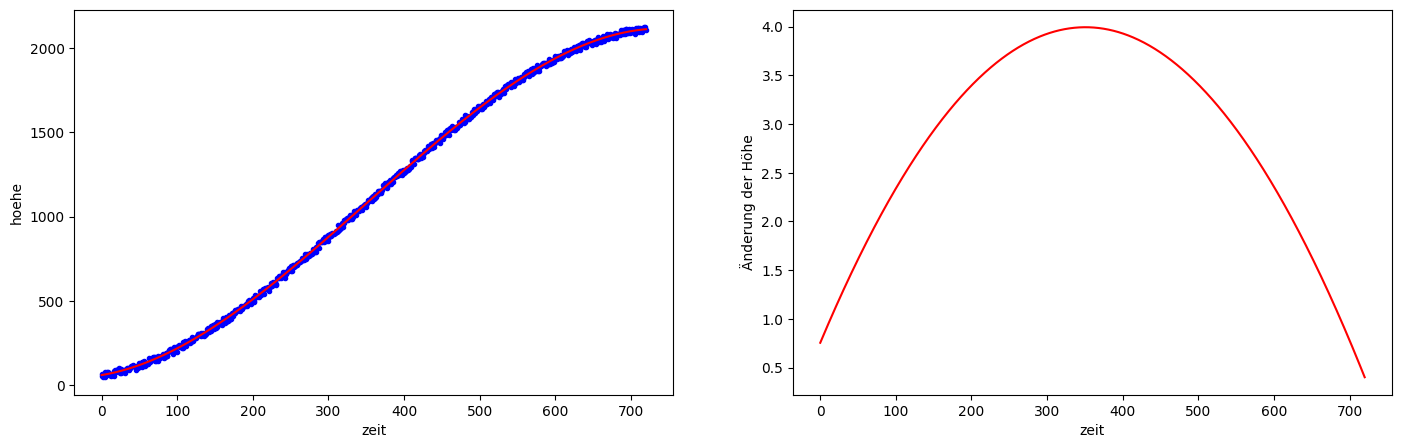

In [8]:
# Fit der Geschwindigkeit:
h_P = np.polyfit(zeit, hoehe, 3)

# Neue x-Stützstellen erstellen:
t_h_reg = np.linspace(np.min(zeit), np.max(zeit), 1000)
h_reg = np.polyval(h_P, t_h_reg)

# Ableitung berechnen:
# Ableiten des Fits
dh_P = np.polyder(h_P)
dh_reg = np.polyval(dh_P, t_h_reg)

# Plotten 
plt.figure(figsize=[17,5])
plt.subplot(121)
plt.plot(zeit, hoehe, '.b')
plt.xlabel('zeit')
plt.ylabel('hoehe')
plt.plot(t_h_reg, h_reg,'r')

plt.subplot(122)
plt.xlabel('zeit')
plt.ylabel('Änderung der Höhe')
plt.plot(t_h_reg, dh_reg,'r')
#plt.plot(t_v, v, '.r')

## Fitting und Interpolation

### Aufgabenteil A1

In der Datei `messwerte.txt` finden Sie 15 Messwerte entsprechend einer leicht verrauschten Normalverteilung. Nutzen Sie `numpy.polyfit`, um Polynome an die Messwerte zu fitten. Erstellen Sie Fits von Grad 1 bis zur Interpolation bei Grad 14 und plotten Sie diese. 

#### Schritt für Schritt Anleitung

1. Importieren Sie die nötigen Pakete (wir wollen rechnen und plotten)
2. Laden Sie die Werte mit NumPy
3. Speichern Sie die x-Werte und die y-Werte jeweils in einer Liste
4. Berechnen Sie den Fit für den Grad 2
5. Plotten Sie das Ergebnis
6. Ändern Sie Ihren Code so um, dass das für alle Grade Plots erstellt werden



<details>
<summary><div style="border:1px solid #bce8f1;background-color:#d9edf7;padding:10px;border-radius:5px;margin:10px 0;cursor:pointer;"><strong>💡 Tipp</strong> (zum Aufklappen)</div></summary>
<div style="border:1px solid #bce8f1;background-color:#d9edf7;padding:10px;border-radius:5px;margin-top:-8px;">
Nutzen Sie eine <code>for</code>-Schleife mit <code>range(1, 15)</code> um alle Polynomgrade von 1 bis 14 (= Interpolation bei 15 Messwerten) zu durchlaufen. Mit <code>plt.subplot(5, 3, grad)</code> können Sie 14 Subplots in einem Raster darstellen.
</div>
</details>

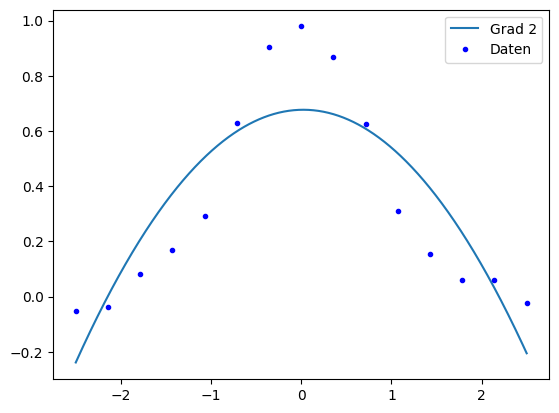

In [13]:
# Importieren der Pakete
import numpy as np
import matplotlib.pyplot as plt

# Laden der Daten
data = np.loadtxt('messwerte.txt', delimiter=' ')

# Speichern der x- und y-Werte
x = data[:,0]
y = data[:,1]

# Berechnen des Fits für den Grad 2
grad = 2
P= np.polyfit(x, y, grad)
x_fit = np.linspace(np.min(x), np.max(x), 1000)
y_fit = np.polyval(P, x_fit)
plt.plot(x_fit, y_fit, label = 'Grad {}'.format(grad))
plt.plot(x,y,'.b', label = 'Daten')
plt.legend()

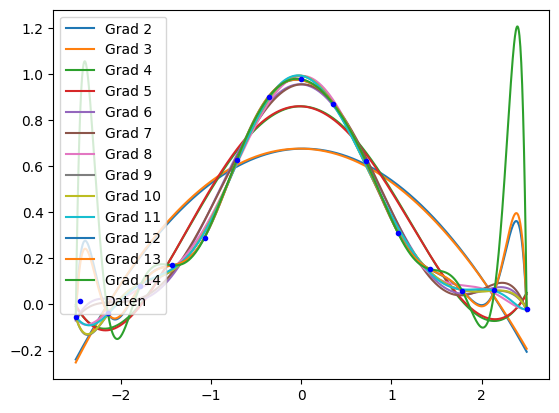

In [ ]:
# Fit und Plot für alle Grade in einem Plot
for grad in range(1, 15):
    P= np.polyfit(x, y, grad)
    x_fit = np.linspace(np.min(x), np.max(x), 1000)
    y_fit = np.polyval(P, x_fit)
    plt.plot(x_fit, y_fit, label = 'Grad {}'.format(grad))
plt.plot(x,y,'.b', label = 'Daten')
plt.legend()

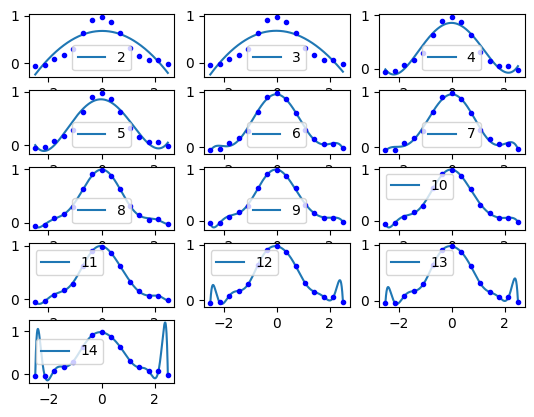

In [17]:
# Fit und Plot für alle Grade in einzelnen Plots
for grad in range(1, 15):
    plt.subplot(5, 3, grad)
    P= np.polyfit(x, y, grad)
    x_fit = np.linspace(np.min(x), np.max(x), 1000)
    y_fit = np.polyval(P, x_fit)
    plt.plot(x_fit, y_fit, label = '{}'.format(grad))
    plt.plot(x,y,'.b')
    plt.legend()

### Aufgabenteil A2

Beantworten Sie folgende Fragen:
1. Warum scheinen manche Fits identisch zu sein?
1. Wenn man, wie in der Vorlesung beschrieben, beliebige Funktionen mit einem Polynom annähern kann und die Messdaten mithilfe einer Funktion erzeugt wurden, wieso wird der Fit ab einem gewissen Grad wieder schlechter?
1. Wie würden sich mehr Messwerte im gleichen Intervall auf die Fits auswirken? 

1. Das manche Fits fast identisch sind hängt mit dem Konvergenzverhalten der Polynome zusammen. Ein Polynom mit einem um eins höheren Grad hat zwar einen Freiheitsgrad mehr, in Form eines zusätzlichen Koeffizienten, allerdings ändert sich die Konvergenz. Polynome mit geradem Grad konvergieren gegen $\pm \infty, \pm \infty$ während solche mit ungradem Grad gegen $\pm \infty, \mp \infty$ konvergieren. Messwerte, die annährend Spiegelsymmetrisch verteilt sind, lasssen sich desswegen oft besser durch Polynome mit geradem Grad annähren und eine Erhöhung zu einem ungeraden Grad führt nur zu kleinen Verbesserungen.
1. Es gibt zwei Gründe, warum der Fit sich nicht kontinuierlich der zugrundeliegenden Funktion annährt. Zum einen sind die Daten verrauscht, was bedetet, dass die unverrauschte Funktion die Daten überhaupt nicht exakt darstellt. Ab einem gewissen Grad, hier 8, stellen die Fits die Daten genauer dar. Der andere Grund ist, dass selbst bei unverrauschten Daten, nicht die zugrundeliegende Funktion angenährt wird, sondern die interpolierte im letzten Plot.
1. Mehr Messwerte bedeuten mehr Information über die Form der ursprünglichen Funktion sowie eine Reduzierung des Einflusses des Rauschens, was beides zu Fits führt, die die unterliegende Funktion besser darstellen.

<div style="border:1px solid #3c763d;background-color:#dff0d8;padding:10px;border-radius:5px;margin:10px 0;">
<strong>✅ Hinweis:</strong> Die L2-Norm misst den Gesamtfehler zwischen Fit und Daten: $\|\hat{y} - y\|_2 = \sum_i (\hat{y}_i - y_i)^2$. Berechnen Sie sie für jeden Polynomgrad und tragen Sie die Werte gegen den Grad auf. Vergleichen Sie mit der Norm zwischen Messdaten und der Originalfunktion $e^{-x^2}$.
</div>

### Aufgabenteil B1

Die Funktion, welche zum Erzeugen der Daten verwendet wurde, ist $\exp(-x^2)$. Berechnen Sie die L2-Norm aller ihrer Fits. Tragen Sie die Abstände gegen den Grad des Fits auf. Berechnen Sie außerdem den Abstand zwischen den Messwerten und der ursprünglichen Funktion und tragen Sie das Ergebnis als Gerade in ihren Fit ein. Fitten Sie die gleichen Daten ein weiteres Mal, diesmal jedoch mit logarithmisch aufgetragenem Abstand. Ignorieren Sie hierbei die Interpolation.

#### Schritt für Schritt Anleitung

1. Importieren Sie die nötigen Pakete (wir wollen rechnen und plotten)
2. Schreiben Sie eine Funktion die zwei Arrays bekommt und die L2-Norm berechnet
$$ \sf || y(x) - (x_i, y_i) ||_2 = \sum_{i=1}^n \left(y(x_i) - y_i\right)^2 \quad $$
3. Berechnen Sie die L2-Norm aus den Daten und den gefitteten Werten und speichern Sie diese Werte in einer Liste
4. Berechnen Sie die Funktionswerte für die gegeben x-Werte mit der oben angegeben Funktion
5. Berechnen Sie die L2-Norm aus den Daten und den berechneten Werten und speichern Sie diese Werte in einer Liste

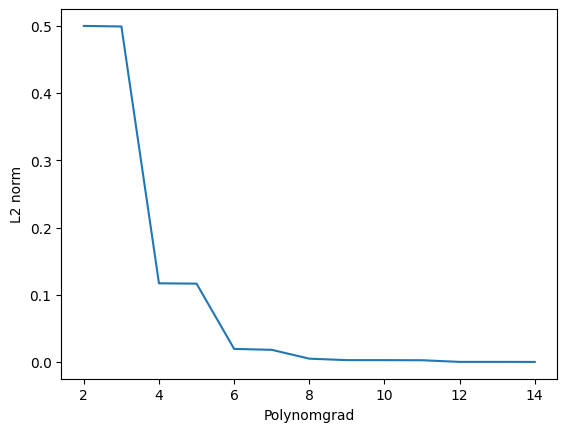

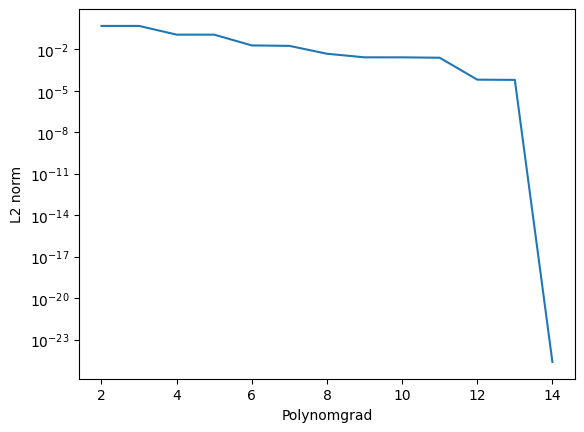

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Funktion, die L2-Norm berechnet
def l2_norm(y, y_fit):
    return np.sum((y - y_fit)**2)

# L2-Norm für alle Fits (Grad 1 bis 13, ohne Interpolation bei 14)
grade = list(range(1, 14))
norm_fits = []
for grad in grade:
    P = np.polyfit(x, y, grad)
    norm_fits.append(l2_norm(y, np.polyval(P, x)))

# L2-Norm zwischen Messdaten und Originalfunktion exp(-x^2)
y_orig = np.exp(-x**2)
norm_orig = l2_norm(y, y_orig)

# Linearer Plot
plt.figure()
plt.plot(grade, norm_fits, 'o-', label='Fit vs. Daten')
plt.axhline(norm_orig, color='r', linestyle='--', label='Originalfunktion vs. Daten')
plt.xlabel('Polynomgrad')
plt.ylabel('L2-Norm')
plt.legend()
plt.title('L2-Norm der Fits')
plt.show()

# Logarithmischer Plot (ohne Interpolation)
plt.figure()
plt.plot(grade, norm_fits, 'o-', label='Fit vs. Daten')
plt.axhline(norm_orig, color='r', linestyle='--', label='Originalfunktion vs. Daten')
plt.xlabel('Polynomgrad')
plt.ylabel('L2-Norm (log)')
plt.yscale('log')
plt.legend()
plt.title('L2-Norm der Fits (logarithmisch)')
plt.show()

### Aufgabenteil B2

Beantworten Sie folgende Fragen:
1. Wann ist eine logarithmische Darstellung von Daten sinnvoll?
1. Wieso haben die Plots Plateaus?
1. Wieso ist es sinnvoll, die Interpolation beim logarithmischen Plot wegzulassen?

1: Eine logarithmische Darstellung von Daten ist oft dann sinnvoll, wenn diese auf mindestens einer Achse mehrere Größenordnungen umfassen und Details in den kleineren Größenordnungen von Bedeutung sind. Wie in den Plots von Aufgabenteil B1 zu sehen, lassen sich so auch bei höheren Polynomgraden Details ablesen, die in dem linearen Plot verloren gegangen sind.

2: Die Plateaus korrespondieren mit der Ähnlichkeit der zugehörigen Fits (siehe Aufgabe A2.1).

3: Da die L2-Norm zwischen der interpolierten Funktion und den Daten bis auf einen numerischen Rundungsfehler Null ist, führt dies zu einem Problem mit der logarithmischen Darstellung, da die Null in dieser nicht dargestellt werden kann. Und auch wenn die Norm nicht ganz Null ist, ist sie um viele Größenordnungen kleiner als die Nrom zwischen vorherigem Grad und Daten, was beim Plotten wieder zu einem Verlust von sichtbaren Details führen würde.

